In [5]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('HotelCustomersDataset.csv', sep='\t')

# Display column names
data['TotalRevenue'] = data['LodgingRevenue'] + data['OtherRevenue']
#print(data.columns)

# Handle missing values
data['Age'].fillna(data['Age'].mean(), inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder() # Fit and transform the Nationality column

data['Nationality'] = label_encoder.fit_transform(data['Nationality'])
data['DistributionChannel'] = label_encoder.fit_transform(data['DistributionChannel'])
data['MarketSegment'] = label_encoder.fit_transform(data['MarketSegment'])

# List of columns to combine
columns_to_combine = ['SRHighFloor', 'SRLowFloor', 'SRAccessibleRoom', 'SRMediumFloor',
                      'SRBathtub', 'SRShower', 'SRCrib', 'SRKingSizeBed', 'SRTwinBed',
                      'SRNearElevator', 'SRAwayFromElevator', 'SRNoAlcoholInMiniBar', 'SRQuietRoom']

# Create a new column that combines the specified columns
data['SpecialRequests'] = data[columns_to_combine].sum(axis=1)

# Remove the original columns
data.drop(columns=columns_to_combine, inplace=True)

# Define features (X) and target variable (y)
X = data.drop(columns=['ID', 'NameHash', 'DocIDHash', 'LodgingRevenue','OtherRevenue','TotalRevenue'])
y = data['TotalRevenue']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




Training set size: 66872
Testing set size: 16718


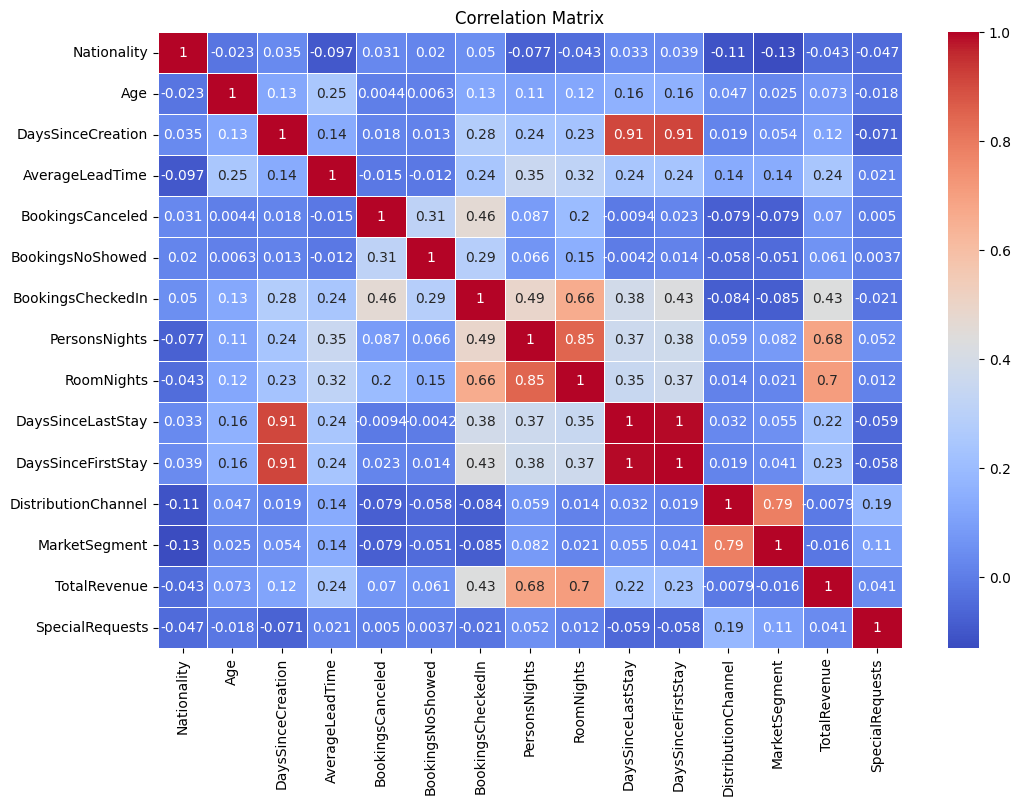

In [6]:
# Calculate the correlation matrix
correlation_matrix = data.drop(columns=['ID', 'NameHash', 'DocIDHash','LodgingRevenue','OtherRevenue']).corr()

# Display the correlation matrix
#print(correlation_matrix)
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [7]:
# Initialize the model using Random Forest
modelRandom = RandomForestRegressor(random_state=42)

# Train the model
modelRandom.fit(X_train, y_train)

# Make predictions
y_pred = modelRandom.predict(X_test)

In [8]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.2f}')

# Feature importance
importances = modelRandom.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print('Feature Importances:')
print(feature_importance_df.head())

Mean Squared Error: 72738.39
R-squared: 0.61
Feature Importances:
             Feature  Importance
8         RoomNights    0.434468
7      PersonsNights    0.111063
3    AverageLeadTime    0.083418
1                Age    0.077138
9  DaysSinceLastStay    0.070026


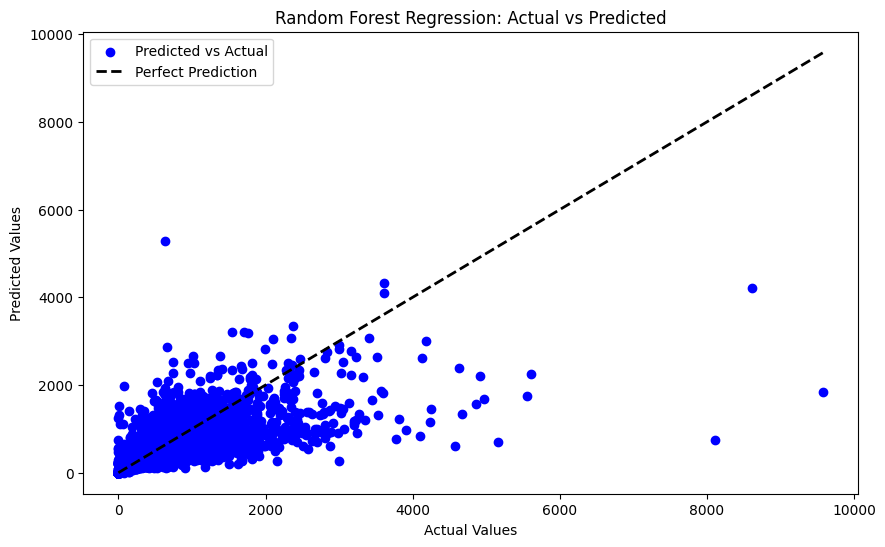

In [9]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regression: Actual vs Predicted')
plt.legend()
plt.show()


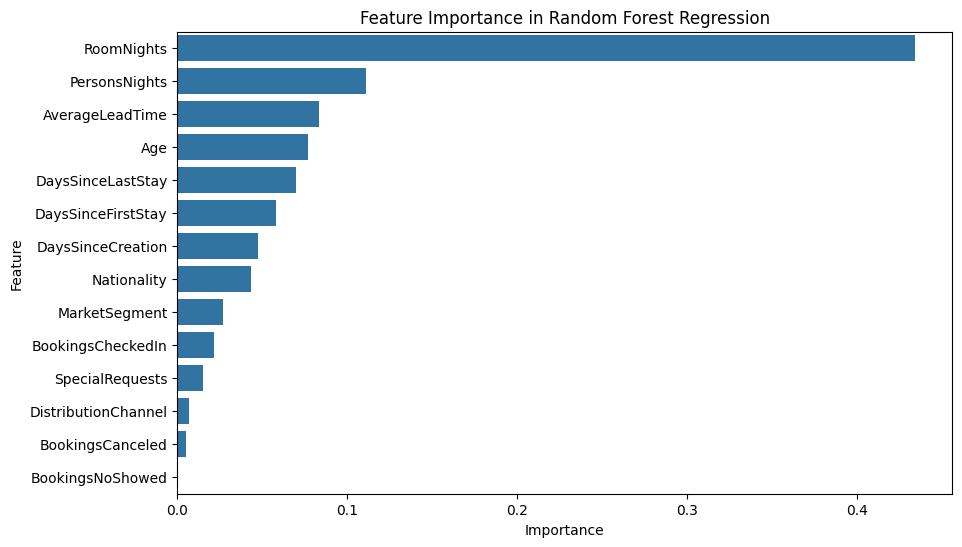

In [10]:
# Feature importance
importances = modelRandom.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance in Random Forest Regression')
plt.show()


In [11]:
# Initialize the model using Linear Regression
modelLinear = LinearRegression()

# Train the model
modelLinear.fit(X_train, y_train)

# Make predictions
y_pred = modelLinear.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.2f}')


Mean Squared Error: 92467.87
R-squared: 0.51


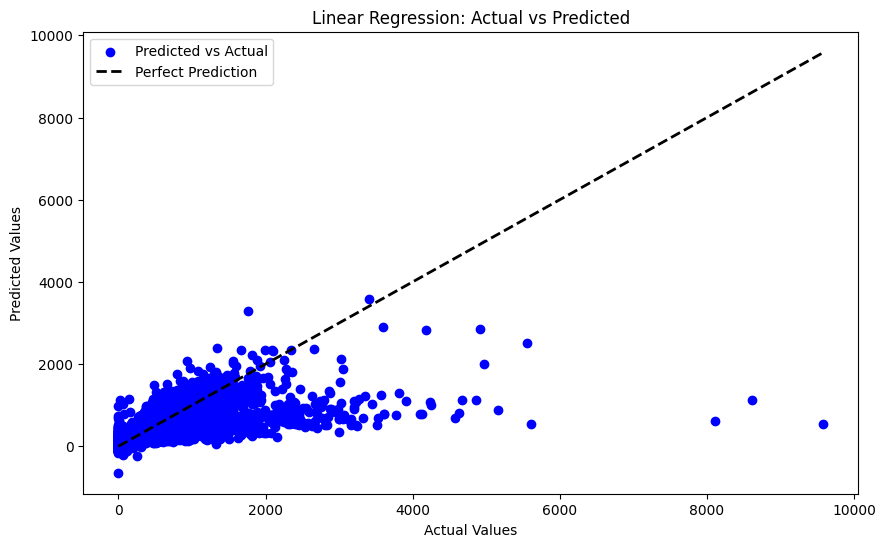

In [12]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()


In [13]:
# Extract the coefficients
coefficients = modelLinear.coef_
# Define features (X) and target variable (y)
#X = data.drop(columns=['ID', 'NameHash', 'DocIDHash', 'LodgingRevenue','OtherRevenue','TotalRevenue'])
#y = data['TotalRevenue']

# Create a DataFrame to hold features and their corresponding coefficients
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Sort the DataFrame by the absolute value of the coefficients
feature_importance_df['Absolute Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute Coefficient', ascending=False)

# Display the top features
print("Top Features based on Coefficients:")
print(feature_importance_df.head())


Top Features based on Coefficients:
               Feature  Coefficient  Absolute Coefficient
8           RoomNights   206.417020            206.417020
7        PersonsNights   138.578335            138.578335
9    DaysSinceLastStay    94.159086             94.159086
10  DaysSinceFirstStay   -89.634609             89.634609
2    DaysSinceCreation   -30.591103             30.591103


In [14]:
# Calculate the correlation matrix
correlation_matrix = data.drop(columns=['ID', 'NameHash', 'DocIDHash','LodgingRevenue','OtherRevenue']).corr()

# Extract the correlation values for 'LodgingRevenue'
correlation_with_revenue = correlation_matrix['TotalRevenue'].drop('TotalRevenue')

# Sort the correlation values in descending order
sorted_correlation = correlation_with_revenue.abs().sort_values(ascending=False)

# Display the top features
print("Top features based on correlation with TotalRevenue:")
print(sorted_correlation.head())



Top features based on correlation with TotalRevenue:
RoomNights            0.704940
PersonsNights         0.684692
BookingsCheckedIn     0.433405
AverageLeadTime       0.243090
DaysSinceFirstStay    0.233216
Name: TotalRevenue, dtype: float64


In [15]:
# Calculate the correlation matrix
correlation_matrix = data.drop(columns=['ID', 'NameHash', 'DocIDHash','TotalRevenue','OtherRevenue']).corr()

# Extract the correlation values for 'LodgingRevenue'
correlation_with_revenue = correlation_matrix['LodgingRevenue'].drop('LodgingRevenue')

# Sort the correlation values in descending order
sorted_correlation = correlation_with_revenue.abs().sort_values(ascending=False)

# Display the top features
print("Top features based on correlation with LodgingRevenue:")
print(sorted_correlation.head())

Top features based on correlation with LodgingRevenue:
RoomNights            0.692154
PersonsNights         0.652267
BookingsCheckedIn     0.423002
AverageLeadTime       0.215844
DaysSinceFirstStay    0.206529
Name: LodgingRevenue, dtype: float64


In [16]:
# Calculate the correlation matrix
correlation_matrix = data.drop(columns=['ID', 'NameHash', 'DocIDHash','TotalRevenue','LodgingRevenue']).corr()

# Extract the correlation values for 'LodgingRevenue'
correlation_with_revenue = correlation_matrix['OtherRevenue'].drop('OtherRevenue')

# Sort the correlation values in descending order
sorted_correlation = correlation_with_revenue.abs().sort_values(ascending=False)

# Display the top features
print("Top features based on correlation with OtherRevenue:")
print(sorted_correlation.head())

Top features based on correlation with OtherRevenue:
PersonsNights         0.530646
RoomNights            0.479166
BookingsCheckedIn     0.302887
AverageLeadTime       0.239713
DaysSinceFirstStay    0.231761
Name: OtherRevenue, dtype: float64


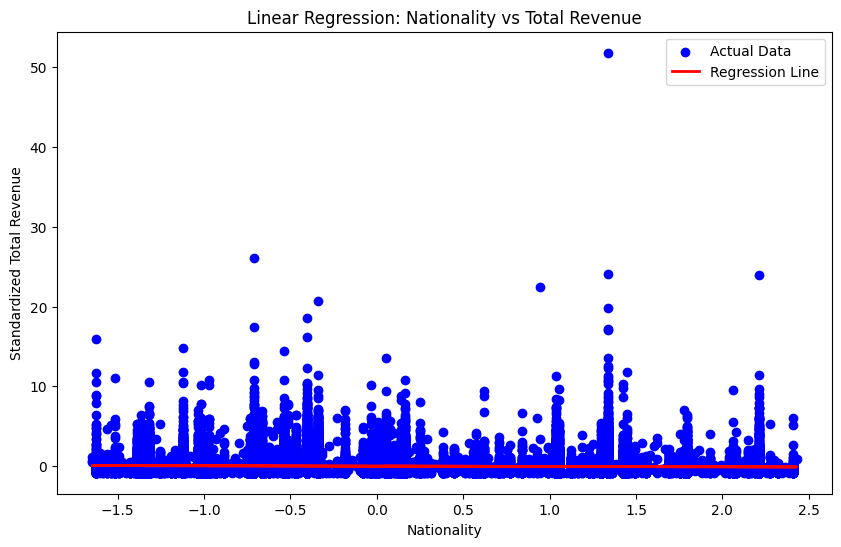

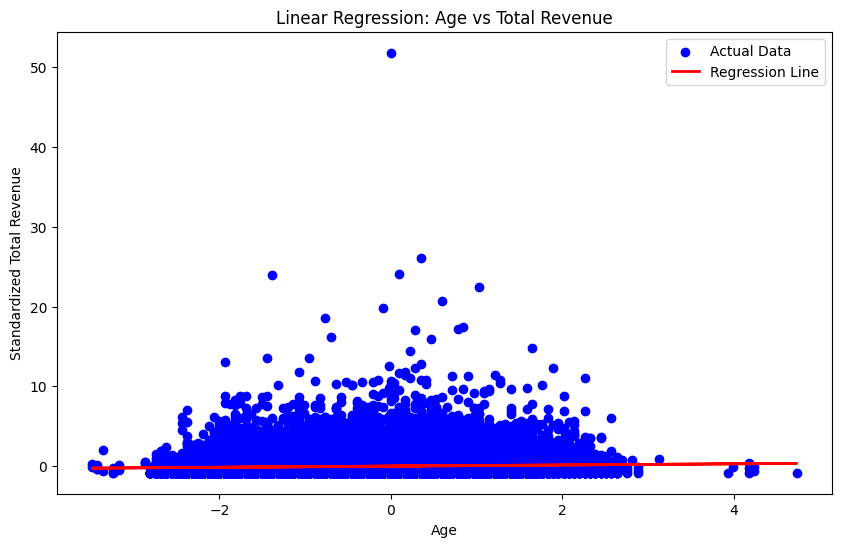

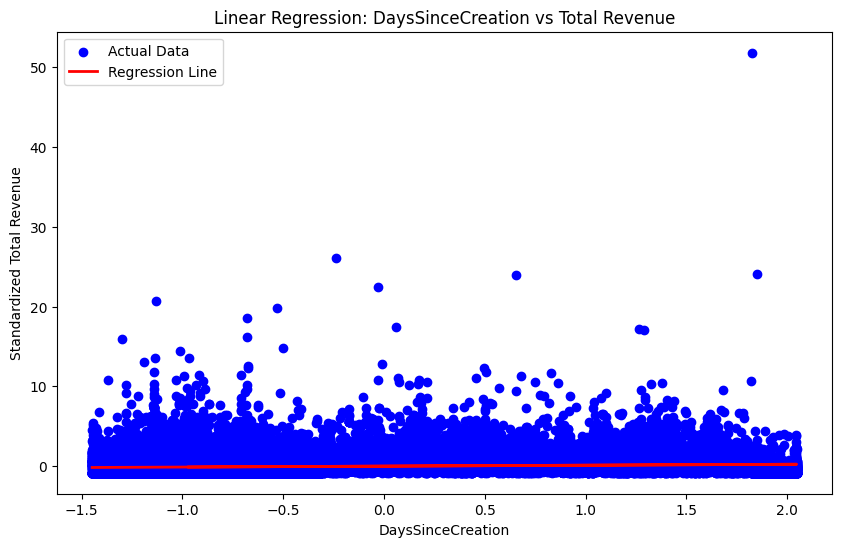

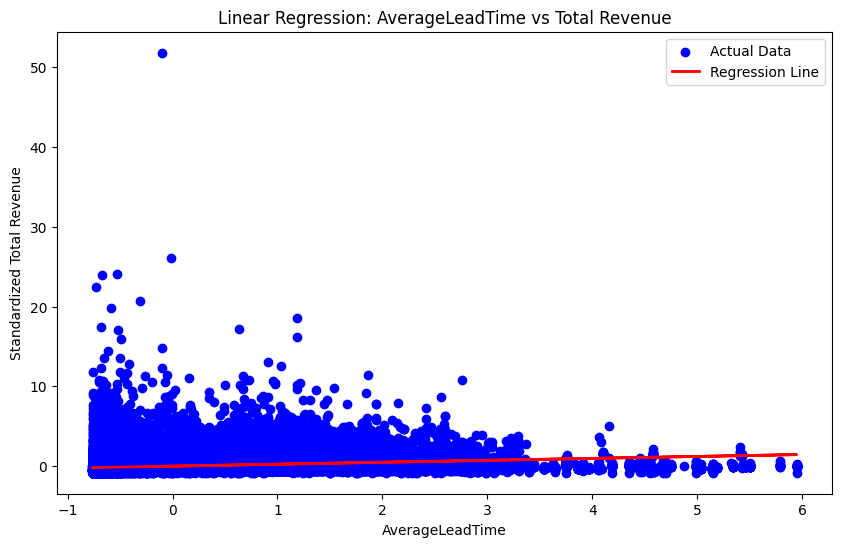

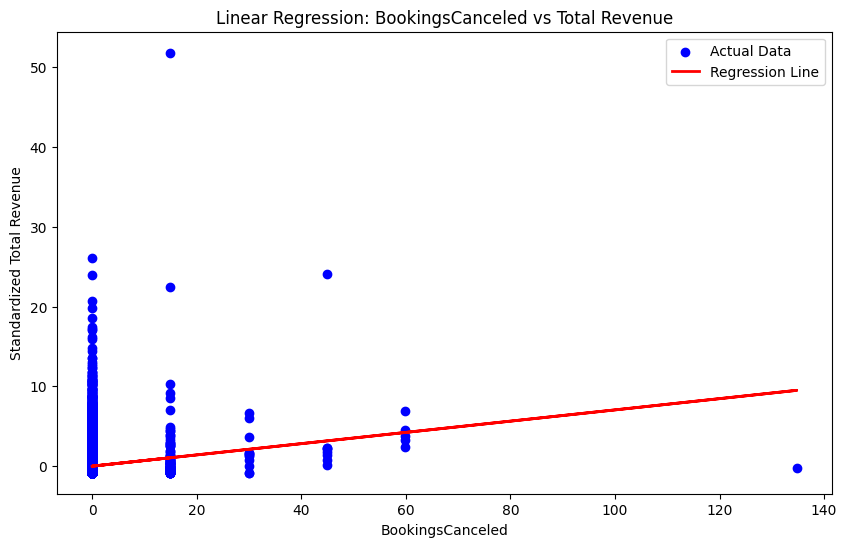

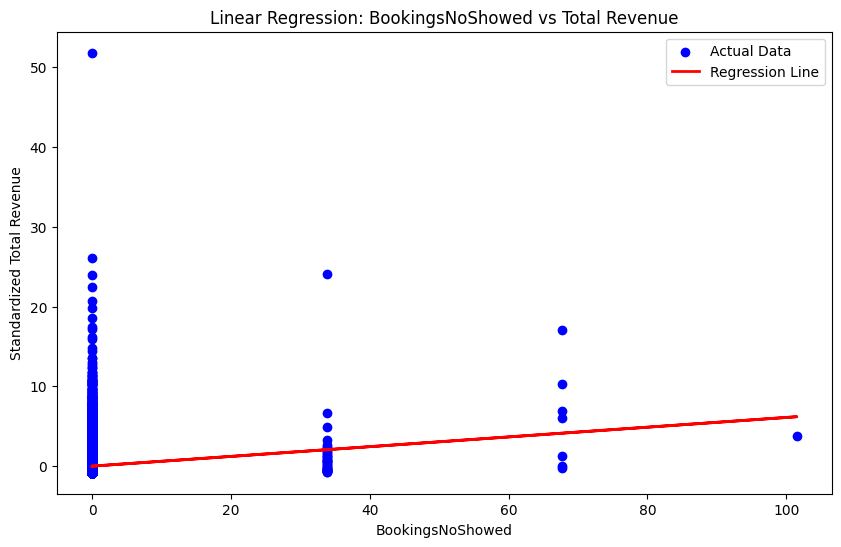

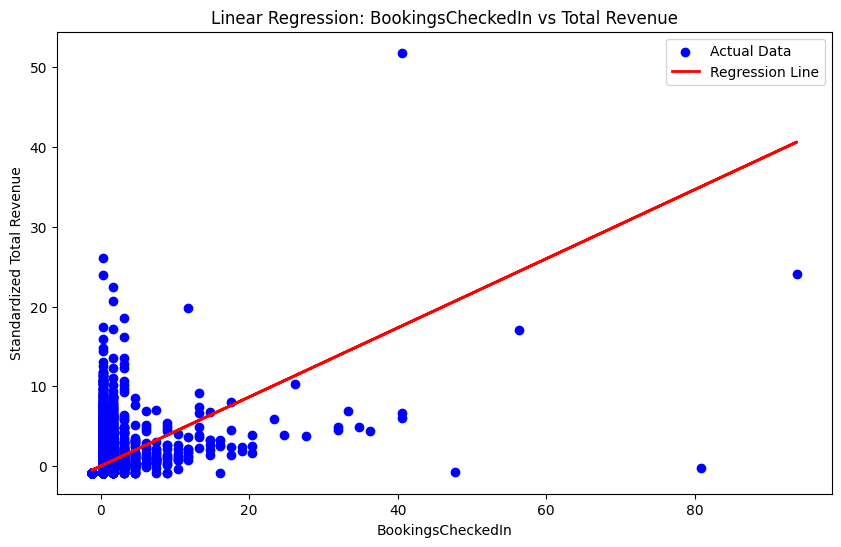

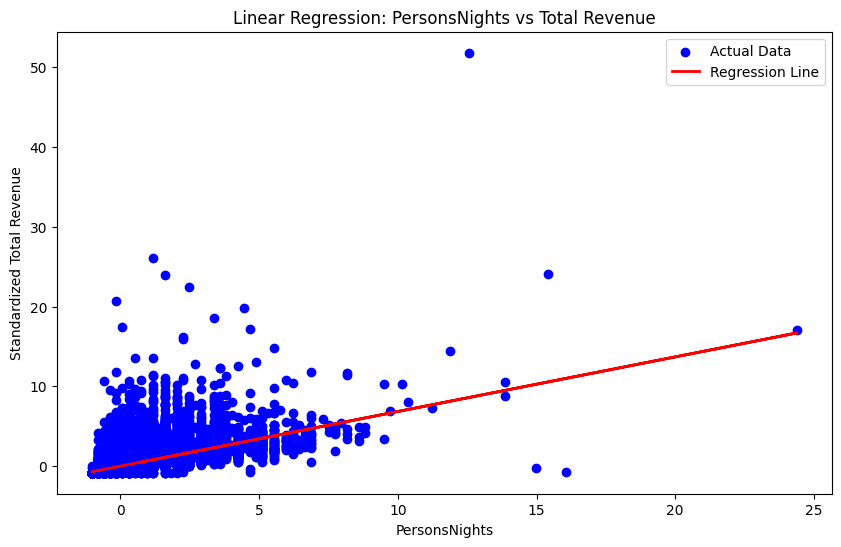

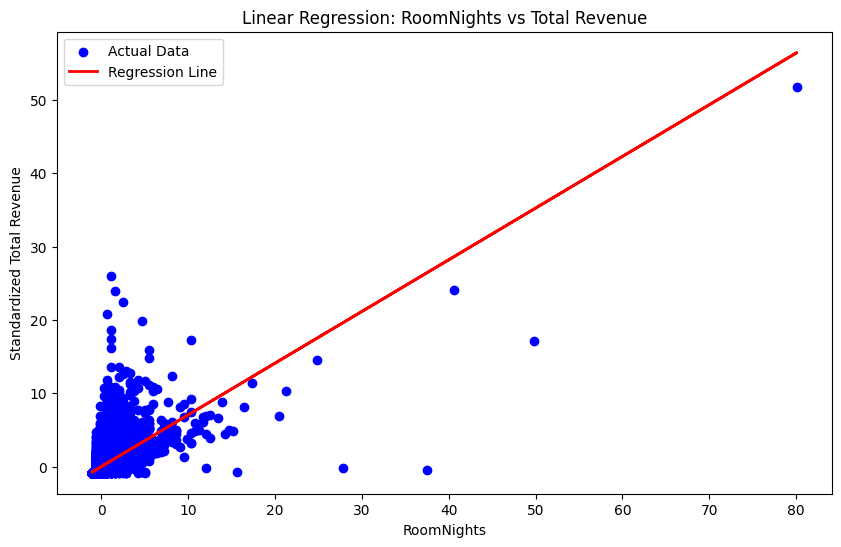

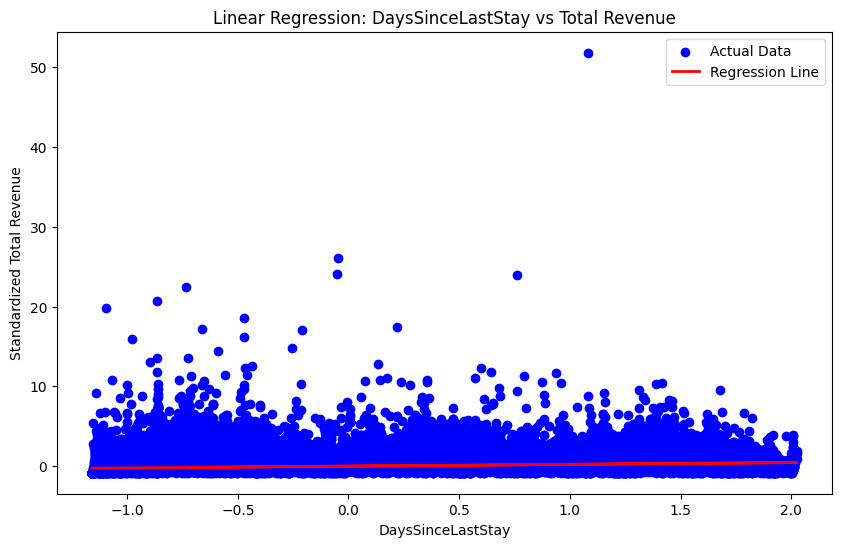

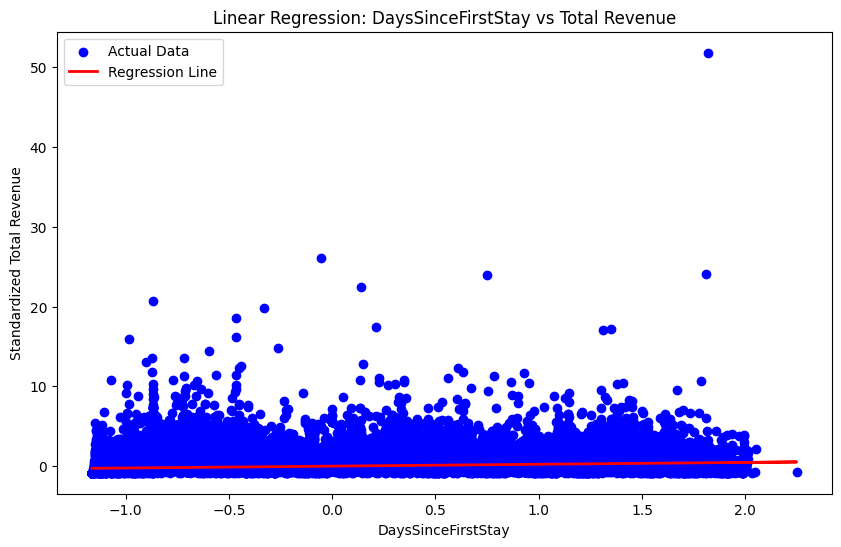

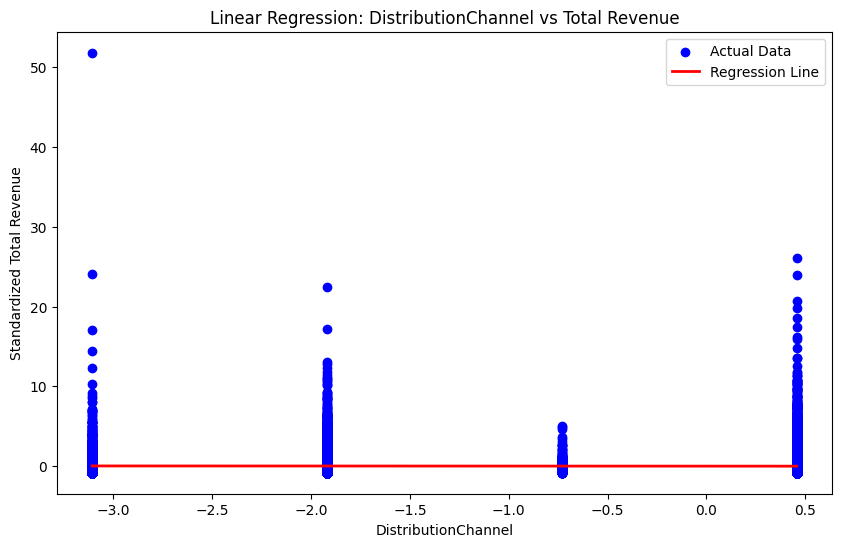

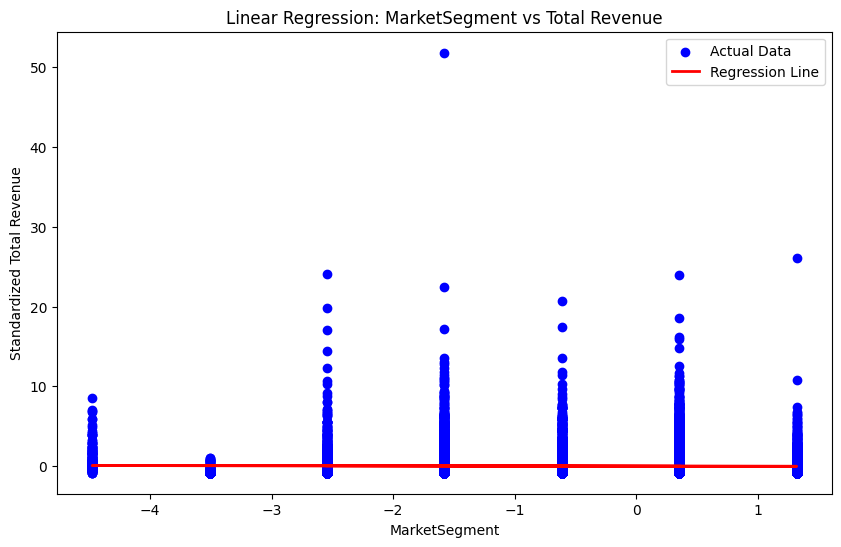

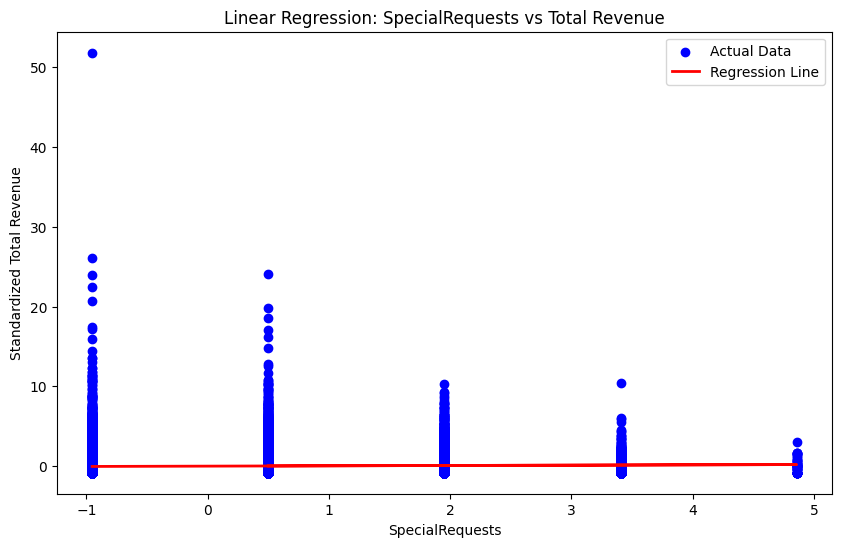

In [17]:
# List of features
features = data.drop(columns=['ID', 'NameHash', 'DocIDHash', 'LodgingRevenue','OtherRevenue','TotalRevenue'])

# Standardize the target variable
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

# Iterate through each feature and plot
for feature in features:
    # Prepare the feature data
    X = data[[feature]].values
    y = data['TotalRevenue']
    # Standardize the feature
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X_scaled, y_scaled)

    # Make predictions
    y_pred = model.predict(X_scaled)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(X_scaled, y_scaled, color='blue', label='Actual Data')
    plt.plot(X_scaled, y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(feature)
    plt.ylabel('Standardized Total Revenue')
    plt.title(f'Linear Regression: {feature} vs Total Revenue')
    plt.legend()
    plt.show()
